In [1]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

X.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=200)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [6]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [7]:
from sklearn.metrics import accuracy_score

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Logistic Regression Accuracy: 1.0
Random Forest Accuracy: 1.0


In [8]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("RF Precision:", precision_score(y_test, y_pred_rf, average='macro'))
print("RF Recall:", recall_score(y_test, y_pred_rf, average='macro'))
print("RF F1:", f1_score(y_test, y_pred_rf, average='macro'))

RF Precision: 1.0
RF Recall: 1.0
RF F1: 1.0


In [9]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)

print("Cross-validation scores:", scores)
print("Average CV Score:", scores.mean())

Cross-validation scores: [0.96666667 0.96666667 0.9        0.93333333 1.        ]
Average CV Score: 0.9533333333333334


In [10]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

y_test_bin = label_binarize(y_test, classes=[0,1,2])

rf_prob = rf.predict_proba(X_test)

print("ROC-AUC:", roc_auc_score(y_test_bin, rf_prob, multi_class='ovr'))

ROC-AUC: 1.0


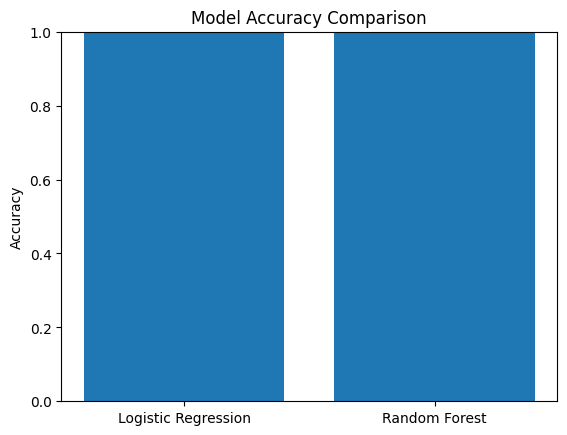

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

models = ["Logistic Regression", "Random Forest"]

accuracy = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_rf)
]

plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()